In [28]:
import sys
# sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/home/mvargas/code/Huawei/survan')

from baseline_cox import SA
from utils import concordance_index, unroll, get_single_task_dataset, kaplan_meier, pad_to, get_single_target_and_mask
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [29]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [30]:
config_path = '../config_server.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [31]:
agent = SA(config, 42)

In [32]:
xs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']
y = agent.data['target']
mask = agent.data['mask']

n, H, _ = xs.shape
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [ ]:
%%time

num_exps = 10
sizes = [.2]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))
res2_td = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))
res3_td = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        res2_is[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:, 0])
        res3_is[fold, i] = concordance_index(scores, ts, cs)
        
        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        res2_lm[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

.

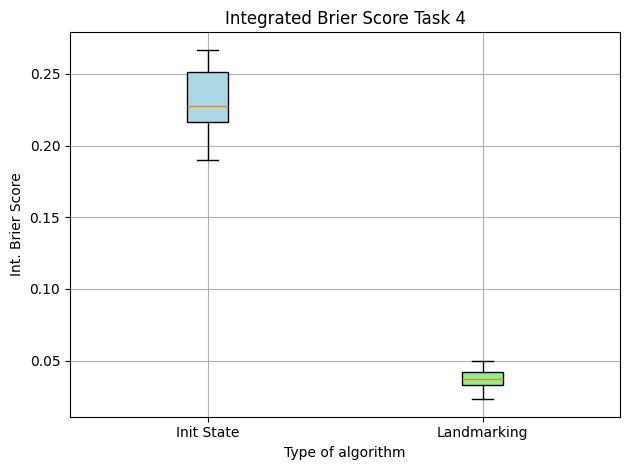

In [26]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res2_is.reshape(-1)
y = res2_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Int. Brier Score")
ax.set_title("Integrated Brier Score Task 4")
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("Int_brier_score_task_10.pdf", format="pdf")

plt.show()

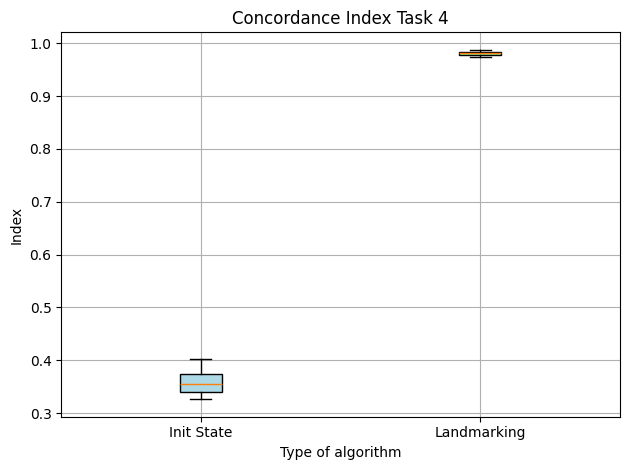

In [27]:

# Create a figure and axis
fig, ax = plt.subplots()

# Set the positions for the boxes
positions = [1, 2]

# Create the boxplots
x = res3_is.reshape(-1)
y = res3_lm.reshape(-1)
boxplot = ax.boxplot([x, y], positions=positions, patch_artist=True)

# Customize the appearance (colors, labels, etc.) as needed
ax.set_xticks(positions)
ax.set_xticklabels(['Init State', 'Landmarking'])
ax.set_xlabel("Type of algorithm")
ax.set_ylabel("Index")
ax.set_title("Concordance Index Task 4")
ax.grid()

# Optionally, fill the boxes with colors
colors = ['lightblue', 'lightgreen']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Save the figure as a PDF with tight layout
plt.tight_layout()  # Ensures a tight layout
plt.savefig("conc_idx_task_10.pdf", format="pdf")

plt.show()


In [17]:
concordance_index(scores, ts, cs)

0.9822634447970059

In [19]:
model.integrated_brier_score(train_gen.X[:, 0], train_gen.ts, train_gen.cs)

Array(0.4562062, dtype=float32)

In [21]:
x

array([0.32902593, 0.37942407, 0.3541794 , 0.35317904, 0.40284143,
       0.32627801, 0.3350691 , 0.3565136 , 0.39159154, 0.35676511])

In [ ]:
def integrated_brier_score(self, xs, ts, cs):
    """Compute the integrated Brier score."""
    cs = cs.astype(jnp.bool_)
    surv = self.survival_curve(xs)
    ws = kaplan_meier(ts - ~cs, ~cs)
    t_max = jnp.max(ts)
    tot = 0.0
    for h in range(1, t_max + 1):
        # Sequences that terminated.
        idx = (ts <= h) & ~cs
        tot += jnp.sum((1 / ws[ts[idx] - 1]) *
                       (0.0 - surv[idx, h - 1]) ** 2)
        # Sequences that are still active.
        idx = (ts > h) | ((ts == h) & cs)
        tot += jnp.sum((1 / ws[h - 1]) * (1.0 - surv[idx, h - 1]) ** 2)
    return tot / (t_max * len(ts))

In [ ]:
def brier_score(seqs, xs, ts, cs, h):
    # Sequences that terminated.
    idx = (ts <= h) & ~cs
    tot += jnp.sum((1 / ws[ts[idx] - 1]) *
                   (0.0 - surv[idx, h - 1]) ** 2)
    # Sequences that are still active.
    idx = (ts > h) | ((ts == h) & cs)
    tot = jnp.sum((1 / ws[h - 1]) * (1.0 - surv[idx, h - 1]) ** 2)
    return tot/(t_max * len(ts))

In [26]:
ws = kaplan_meier(ts - ~cs, ~cs)

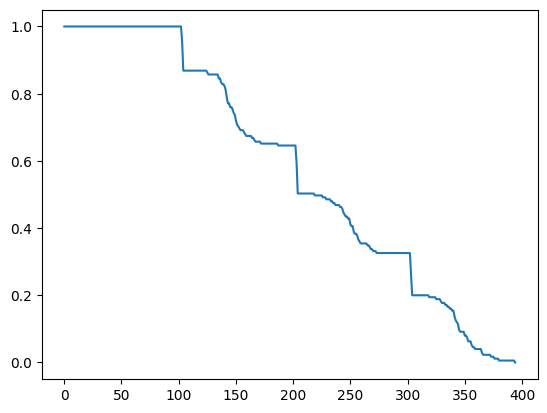

In [30]:
plt.plot(ws)

In [32]:
h = 10

surv = model.survival_curve(seqs)

# Sequences that terminated.
idx = (ts <= h) & ~cs
tot = jnp.sum((1 / ws[ts[idx] - 1]) *
               (0.0 - surv[idx, h - 1]) ** 2)
# Sequences that are still active.
idx = (ts > h) | ((ts == h) & cs)
tot = jnp.sum((1 / ws[h - 1]) * (1.0 - surv[idx, h - 1]) ** 2)


In [6]:
train_seqs = train_gen.X[:10]
surv = model.survival_curve(train_seqs)

NameError: name 'train_gen' is not defined

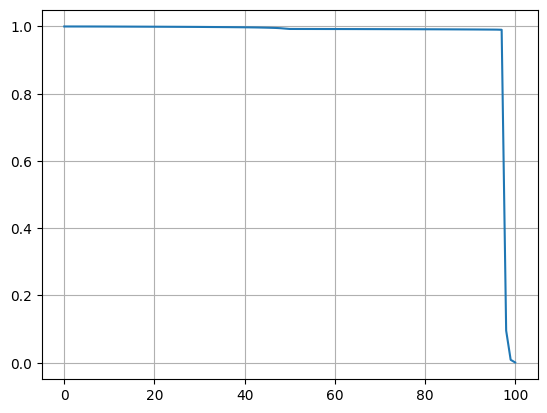

In [50]:
plt.plot(surv[4])
plt.grid()
plt.show()

In [66]:
train_gen.ts[:10]

Array([104, 103, 104, 103, 303,   5,   5, 103, 139, 348], dtype=int32)

In [67]:
target = train_gen.y[5]

In [71]:
t = train_gen.ts[5]
t

Array(5, dtype=int32)

In [76]:
c = train_gen.cs[5]
c

Array(False, dtype=bool)

In [69]:
train_gen.mask[5][0]

Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],      dtype=float32)

In [94]:
target.shape

(100, 100)

In [99]:
mask = jnp.tril(jnp.ones_like(target), -((target.shape[0]-t.item())))[::-1]

In [96]:
mask

Array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [15]:
seq = agent.data['seqs'][3]
t = agent.data['ts'][3]
c = agent.data['cs'][3]
print(t, c)

5 False


In [18]:
target, mask = get_single_target_and_mask(seq, t, c, False)

In [19]:
mask[:7, :7]

Array([[1., 1., 1., 1., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [98]:
target[0]

Array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32)

In [12]:
ts = agent.data['ts']
jnp.where(ts == 5)

(Array([  3,   7,  11,  15,  19,  27,  31,  35,  39,  43,  55,  59,  63,
         67,  71,  75,  83,  99, 103, 107, 115, 119, 123, 131, 139, 151,
        155, 163, 167, 171, 175, 179, 183, 191, 195, 199, 203, 207, 211,
        219, 227, 231, 235, 239, 247, 251, 255, 259, 263, 283, 287, 291,
        295, 307, 311, 327, 331, 339, 347, 351, 355, 367, 371, 383, 387,
        395, 399, 407, 419, 423, 427, 439, 447, 451, 459, 467, 471, 475,
        479, 483, 487, 491, 495, 499, 507, 515, 519, 531, 539],      dtype=int32),)

In [13]:
ts[3]

Array(5, dtype=int32)